In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("/Users/ameypatil/Desktop/Tata Power/data/final.csv")

In [3]:
# Drop unwanted columns
df = df.drop(columns=['_id_x', '_id_y'])

# Datetime handling
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

# Feature
df['hour'] = df['datetime'].dt.hour

# Drop NaN
df = df.dropna()

In [4]:
Y = df['wdLoad'].values        # outcome
T = df[['temp', 'rh']].values          # treatment
X = df[['hour']].values   # controls

In [5]:

from xgboost import XGBRegressor



model = CausalForestDML(
    model_y=XGBRegressor(),
    model_t=XGBRegressor(),
    n_estimators=100,
    min_samples_leaf=10,
    random_state=42
)

model.fit(Y, T, X=X)

In [6]:
effects = model.const_marginal_effect(X)

In [7]:
ate_temp = np.mean(effects[:,0])
ate_rh = np.mean(effects[:,1])

print("ATE (Temperature):", ate_temp)
print("ATE (Humidity):", ate_rh)

ATE (Temperature): 8.528896500300021
ATE (Humidity): 0.4234558695166023


In [9]:
df_effect = pd.DataFrame(X, columns=['hour','rh'])
df_effect['effect'] = effects

effect_by_hour = df_effect.groupby('hour')['effect'].mean()
print(effect_by_hour)
plt.figure(figsize=(10,6))
plt.plot(effect_by_hour.index, effect_by_hour.values, marker='o')

plt.xlabel("Hour")
plt.ylabel("Treatment Effect")
plt.title("Temperature Effect by Hour")

plt.grid(alpha=0.3)
plt.show()

ValueError: Shape of passed values is (288897, 1), indices imply (288897, 2)

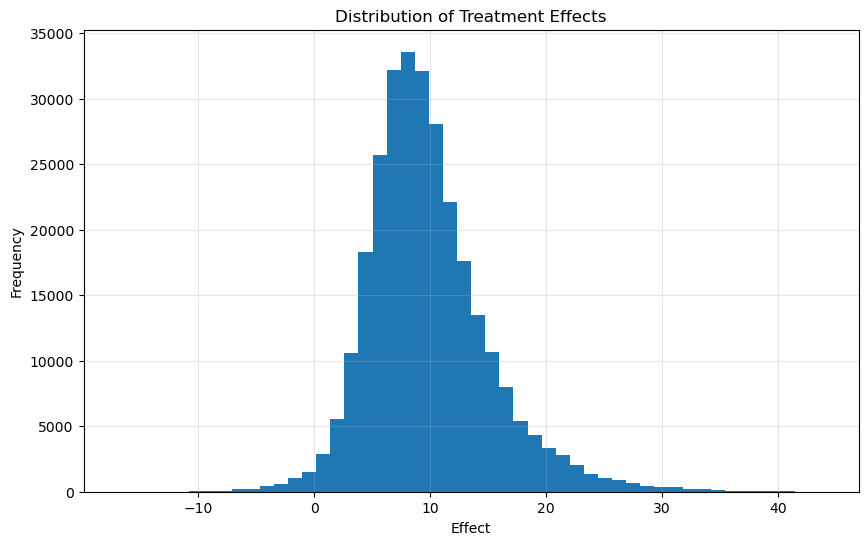

In [9]:
plt.figure(figsize=(10,6))

plt.hist(effects, bins=50)

plt.xlabel("Effect")
plt.ylabel("Frequency")
plt.title("Distribution of Treatment Effects")

plt.grid(alpha=0.3)
plt.show()